# Bank Marketing Analytics & Subscription Prediction

## 03 — SQL Business Analysis

This notebook uses SQLite and SQL to analyze the cleaned UCI Bank Marketing dataset from a business perspective.

### Objectives

- Validate the SQLite analytical database.
- Calculate overall campaign performance.
- Compare subscription rates across customer and campaign segments.
- Use `GROUP BY`, aggregations, `CASE WHEN`, CTEs, and window functions.
- Distinguish between conversion rate, subscriber volume, and segment scale.
- Translate SQL results into business-oriented observations.

> The analysis is observational. Segment-level differences should not be interpreted as causal effects.

In [31]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def locate_project_root(start_path: Path) -> Path:
    """Locate the project root from the current notebook directory."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        database_path = (
            candidate
            / "data"
            / "interim"
            / "bank_marketing.db"
        )

        sql_file_path = (
            candidate
            / "sql"
            / "business_analysis.sql"
        )

        if database_path.exists() and sql_file_path.exists():
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run src/database.py and src/sql_analysis.py first."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.sql_analysis import (
    DATABASE_PATH,
    OUTPUT_DIRECTORY,
    SQL_FILE_PATH,
    execute_queries,
    load_named_queries,
    validate_results,
)


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Database path: {DATABASE_PATH}")
print(f"SQL file path: {SQL_FILE_PATH}")

Project root: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml
Database path: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\data\interim\bank_marketing.db
SQL file path: C:\Users\omary\Documents\VS Code\bank-marketing-analytics-ml\sql\business_analysis.sql


## 1. Load and Validate the Named SQL Queries

The SQL queries are stored in `sql/business_analysis.sql` rather than being hidden inside the notebook.

Each query is identified by a `-- name:` marker. Python loads the named queries, executes them against SQLite, and validates their outputs.

In [32]:
queries = load_named_queries()
results = execute_queries(queries)

validate_results(results)

print(f"Named SQL queries loaded: {len(queries)}")
print("\nQuery names:")

for query_name in queries:
    print(f"- {query_name}")

print(
    "\nAll SQL query results were loaded "
    "and validated successfully."
)

Named SQL queries loaded: 11

Query names:
- dataset_overview
- subscription_by_job
- subscription_by_education
- subscription_by_contact_type
- subscription_by_month
- subscription_by_previous_outcome
- average_balance_by_subscription
- conversion_by_age_group
- conversion_by_campaign_contacts
- job_performance_ranking
- scalable_segment_ranking

All SQL query results were loaded and validated successfully.


In [33]:
def display_sql_query(
    query_name: str,
    preview_rows: int | None = None,
) -> pd.DataFrame:
    """Display a named SQL query and its result."""
    if query_name not in queries:
        raise KeyError(
            f"Unknown SQL query: {query_name}"
        )

    display(
        Markdown(
            f"### SQL Query: `{query_name}`"
        )
    )

    display(
        Markdown(
            f"```sql\n{queries[query_name]}\n```"
        )
    )

    result = results[query_name]

    if preview_rows is None:
        display(result)
    else:
        display(result.head(preview_rows))

    return result

## 2. Overall Campaign Performance

The first query establishes the campaign baseline:

- Total number of contacted clients.
- Number of subscribers.
- Number of non-subscribers.
- Overall subscription rate.

This baseline is necessary when comparing individual segment rates.

In [34]:
dataset_overview = display_sql_query(
    "dataset_overview"
)

### SQL Query: `dataset_overview`

```sql
-- High-level dataset and conversion summary.

SELECT
    COUNT(*) AS total_clients,
    SUM(subscribed) AS subscribers,
    COUNT(*) - SUM(subscribed) AS non_subscribers,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS overall_subscription_rate
FROM bank_marketing;
```

,total_clients,subscribers,non_subscribers,overall_subscription_rate
0,45211,5289,39922,11.70


## 3. Subscription Performance by Job

The job analysis distinguishes between three measures:

- `subscription_rate`: the percentage subscribing within a job category.
- `subscriber_count`: the absolute number of subscribers from the category.
- `share_of_all_subscribers`: the category's contribution to all successful subscriptions.

A category can have a high conversion rate but contribute relatively few total subscribers if it is small.

In [35]:
job_summary = display_sql_query(
    "subscription_by_job"
)

### SQL Query: `subscription_by_job`

```sql
-- Customer volume and subscription performance by job.

SELECT
    job,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate,
    ROUND(AVG(balance), 2) AS average_balance
FROM bank_marketing
GROUP BY job
ORDER BY
    subscription_rate DESC,
    client_count DESC;
```

,job,client_count,subscriber_count,subscription_rate,average_balance
0,student,938,269,28.68,"1,388.06"
1,retired,2264,516,22.79,"1,984.22"
2,unemployed,1303,202,15.50,"1,521.75"
3,management,9458,1301,13.76,"1,763.62"
4,admin.,5171,631,12.20,"1,135.84"
5,self-employed,1579,187,11.84,"1,647.97"
6,unknown,288,34,11.81,"1,772.36"
7,technician,7597,840,11.06,"1,252.63"
8,services,4154,369,8.88,997.09
9,housemaid,1240,109,8.79,"1,392.40"


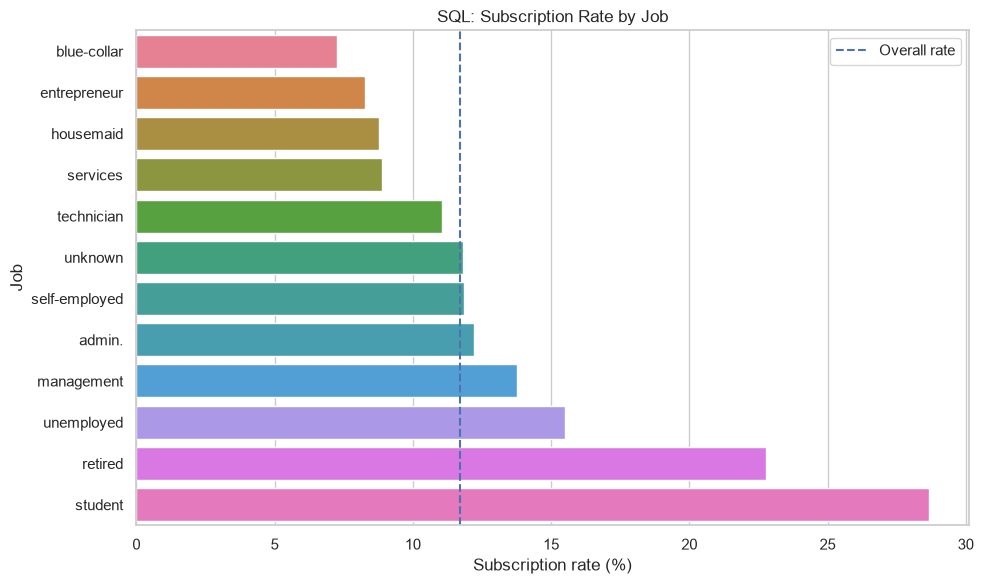

In [36]:
job_plot_data = (
    job_summary
    .sort_values(
        "subscription_rate",
        ascending=True,
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=job_plot_data,
    x="subscription_rate",
    y="job",
    hue="job",
    legend=False,
    ax=axis,
)

axis.axvline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
    label="Overall rate",
)

axis.set_title("SQL: Subscription Rate by Job")
axis.set_xlabel("Subscription rate (%)")
axis.set_ylabel("Job")
axis.legend()

plt.tight_layout()
plt.show()

## 4. Job Ranking with Window Functions

The job-performance query uses SQL window functions:

- `DENSE_RANK()` ranks jobs by subscription rate.
- `SUM(...) OVER ()` calculates each job's share of all subscribers without collapsing the grouped rows.

This analysis shows why conversion rate and subscriber volume should be evaluated together.

In [37]:
job_ranking = display_sql_query(
    "job_performance_ranking"
)

### SQL Query: `job_performance_ranking`

```sql
-- Rank job categories and calculate each job's share of subscribers.

WITH job_performance AS (
    SELECT
        job,
        COUNT(*) AS client_count,
        SUM(subscribed) AS subscriber_count,
        ROUND(
            100.0 * SUM(subscribed) / COUNT(*),
            2
        ) AS subscription_rate
    FROM bank_marketing
    GROUP BY job
)
SELECT
    job,
    client_count,
    subscriber_count,
    subscription_rate,
    DENSE_RANK() OVER (
        ORDER BY subscription_rate DESC
    ) AS subscription_rate_rank,
    ROUND(
        100.0 * subscriber_count
        / SUM(subscriber_count) OVER (),
        2
    ) AS share_of_all_subscribers
FROM job_performance
ORDER BY
    subscription_rate_rank,
    subscriber_count DESC;
```

,job,client_count,subscriber_count,subscription_rate,subscription_rate_rank,share_of_all_subscribers
0,student,938,269,28.68,1,5.09
1,retired,2264,516,22.79,2,9.76
2,unemployed,1303,202,15.50,3,3.82
3,management,9458,1301,13.76,4,24.60
4,admin.,5171,631,12.20,5,11.93
5,self-employed,1579,187,11.84,6,3.54
6,unknown,288,34,11.81,7,0.64
7,technician,7597,840,11.06,8,15.88
8,services,4154,369,8.88,9,6.98
9,housemaid,1240,109,8.79,10,2.06


In [38]:
job_ranking_comparison = job_ranking[
    [
        "job",
        "subscription_rate",
        "subscription_rate_rank",
        "subscriber_count",
        "share_of_all_subscribers",
    ]
].copy()

display(job_ranking_comparison)

,job,subscription_rate,subscription_rate_rank,subscriber_count,share_of_all_subscribers
0,student,28.68,1,269,5.09
1,retired,22.79,2,516,9.76
2,unemployed,15.50,3,202,3.82
3,management,13.76,4,1301,24.60
4,admin.,12.20,5,631,11.93
5,self-employed,11.84,6,187,3.54
6,unknown,11.81,7,34,0.64
7,technician,11.06,8,840,15.88
8,services,8.88,9,369,6.98
9,housemaid,8.79,10,109,2.06


### Job-Segment Interpretation

Students have the highest subscription rate, but the management segment contributes a substantially larger number and share of total subscribers.

This illustrates an important business distinction:

- **Conversion efficiency:** how successfully a segment converts.
- **Campaign scale:** how many clients and subscriptions the segment represents.

A practical targeting strategy should consider both measures.

## 5. Monthly Campaign Performance Using a CTE

The monthly query uses a CTE containing a month-number lookup.

This ensures that months are ordered chronologically rather than alphabetically.

In [39]:
month_summary = display_sql_query(
    "subscription_by_month"
)

### SQL Query: `subscription_by_month`

```sql
-- Monthly campaign performance using a CTE for calendar ordering.

WITH month_lookup (
    month_name,
    month_number
) AS (
    VALUES
        ('jan', 1),
        ('feb', 2),
        ('mar', 3),
        ('apr', 4),
        ('may', 5),
        ('jun', 6),
        ('jul', 7),
        ('aug', 8),
        ('sep', 9),
        ('oct', 10),
        ('nov', 11),
        ('dec', 12)
)
SELECT
    marketing.contact_month,
    month_lookup.month_number,
    COUNT(*) AS client_count,
    SUM(marketing.subscribed) AS subscriber_count,
    ROUND(
        100.0
        * SUM(marketing.subscribed)
        / COUNT(*),
        2
    ) AS subscription_rate
FROM bank_marketing AS marketing
INNER JOIN month_lookup
    ON marketing.contact_month
       = month_lookup.month_name
GROUP BY
    marketing.contact_month,
    month_lookup.month_number
ORDER BY month_lookup.month_number;
```

,contact_month,month_number,client_count,subscriber_count,subscription_rate
0,jan,1,1403,142,10.12
1,feb,2,2649,441,16.65
2,mar,3,477,248,51.99
3,apr,4,2932,577,19.68
4,may,5,13766,925,6.72
5,jun,6,5341,546,10.22
6,jul,7,6895,627,9.09
7,aug,8,6247,688,11.01
8,sep,9,579,269,46.46
9,oct,10,738,323,43.77


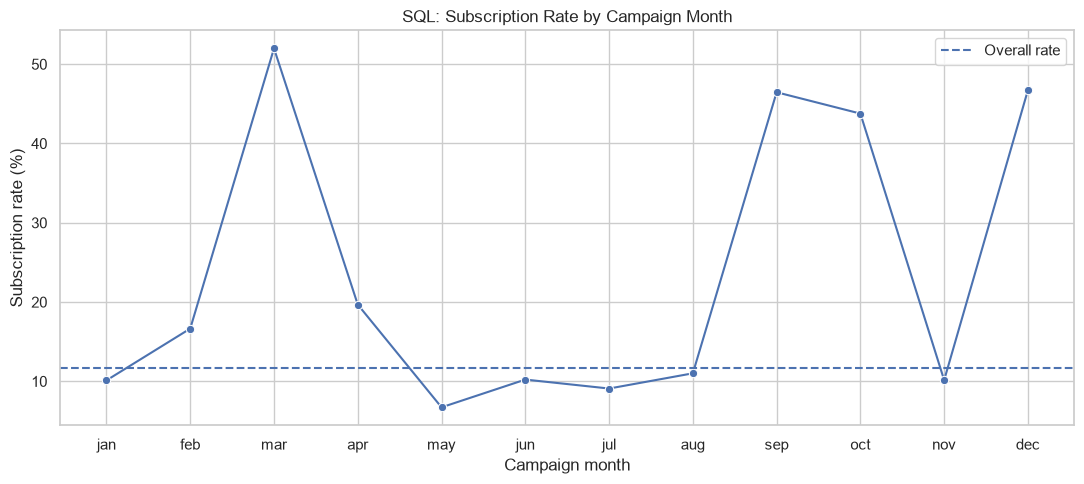

In [40]:
figure, axis = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=month_summary,
    x="month_number",
    y="subscription_rate",
    marker="o",
    ax=axis,
)

axis.axhline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
    label="Overall rate",
)

axis.set_xticks(
    month_summary["month_number"],
    month_summary["contact_month"],
)

axis.set_title("SQL: Subscription Rate by Campaign Month")
axis.set_xlabel("Campaign month")
axis.set_ylabel("Subscription rate (%)")
axis.legend()

plt.tight_layout()
plt.show()

## 6. Previous Campaign Outcome

Previous campaign outcomes may contain useful information about historical customer interest.

The `unknown` category is retained because it often represents clients without a recorded or meaningful previous campaign outcome.

In [41]:
previous_outcome_summary = display_sql_query(
    "subscription_by_previous_outcome"
)

### SQL Query: `subscription_by_previous_outcome`

```sql
-- Performance by previous campaign outcome.

SELECT
    previous_outcome,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate,
    ROUND(AVG(previous_contacts), 2)
        AS average_previous_contacts
FROM bank_marketing
GROUP BY previous_outcome
ORDER BY
    subscription_rate DESC,
    client_count DESC;
```

,previous_outcome,client_count,subscriber_count,subscription_rate,average_previous_contacts
0,success,1511,978,64.73,3.08
1,other,1840,307,16.68,4.01
2,failure,4901,618,12.61,2.90
3,unknown,36959,3386,9.16,0.00


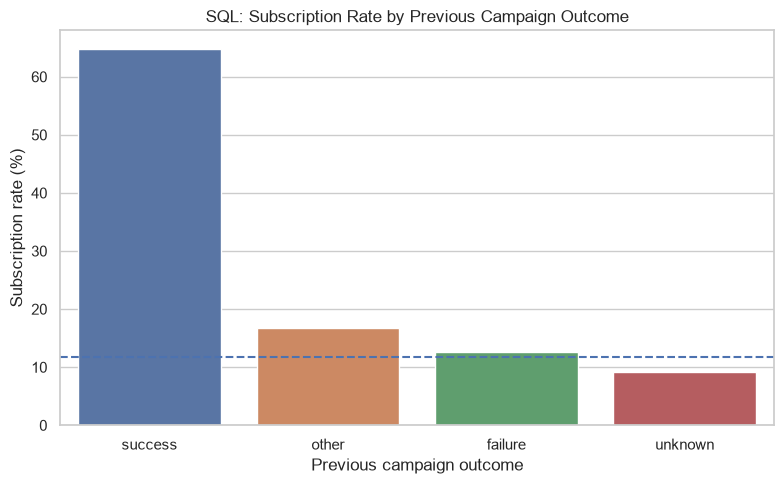

In [42]:
figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=previous_outcome_summary,
    x="previous_outcome",
    y="subscription_rate",
    hue="previous_outcome",
    legend=False,
    ax=axis,
)

axis.axhline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
)

axis.set_title(
    "SQL: Subscription Rate by Previous Campaign Outcome"
)
axis.set_xlabel("Previous campaign outcome")
axis.set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

### Previous-Outcome Interpretation

Clients with a previous successful outcome show a substantially higher subscription rate.

This is an association rather than proof of causation. The result may reflect persistent customer interest, earlier targeting decisions, or other customer characteristics.

## 7. Conversion by Current-Campaign Contact Count

The SQL query uses a CTE and `CASE WHEN` to convert the numerical contact count into business-friendly groups.

A lower observed rate among repeatedly contacted clients does not prove that additional contact attempts caused lower conversion. Difficult-to-convert customers may naturally receive more attempts.

In [43]:
campaign_contact_summary = display_sql_query(
    "conversion_by_campaign_contacts"
)

### SQL Query: `conversion_by_campaign_contacts`

```sql
-- Conversion rates by current-campaign contact intensity.

WITH campaign_segments AS (
    SELECT
        CASE
            WHEN campaign_contacts = 1
                THEN '1 contact'
            WHEN campaign_contacts BETWEEN 2 AND 3
                THEN '2-3 contacts'
            WHEN campaign_contacts BETWEEN 4 AND 5
                THEN '4-5 contacts'
            WHEN campaign_contacts BETWEEN 6 AND 10
                THEN '6-10 contacts'
            ELSE '11+ contacts'
        END AS campaign_contact_group,
        subscribed
    FROM bank_marketing
)
SELECT
    campaign_contact_group,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate
FROM campaign_segments
GROUP BY campaign_contact_group
ORDER BY
    CASE campaign_contact_group
        WHEN '1 contact' THEN 1
        WHEN '2-3 contacts' THEN 2
        WHEN '4-5 contacts' THEN 3
        WHEN '6-10 contacts' THEN 4
        WHEN '11+ contacts' THEN 5
    END;
```

,campaign_contact_group,client_count,subscriber_count,subscription_rate
0,1 contact,17544,2561,14.60
1,2-3 contacts,18026,2019,11.20
2,4-5 contacts,5286,456,8.63
3,6-10 contacts,3159,206,6.52
4,11+ contacts,1196,47,3.93


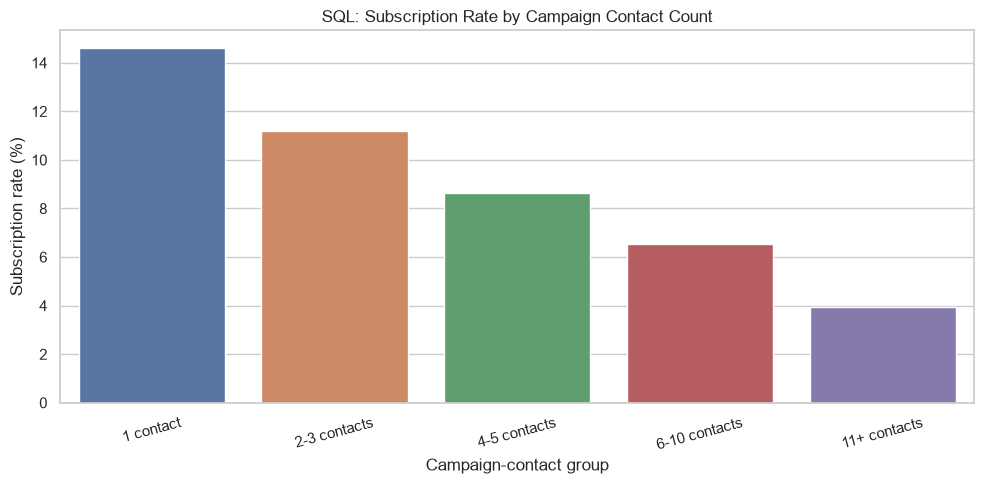

In [44]:
figure, axis = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=campaign_contact_summary,
    x="campaign_contact_group",
    y="subscription_rate",
    hue="campaign_contact_group",
    legend=False,
    ax=axis,
)

axis.set_title(
    "SQL: Subscription Rate by Campaign Contact Count"
)
axis.set_xlabel("Campaign-contact group")
axis.set_ylabel("Subscription rate (%)")
axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [45]:
assert len(queries) == 11

assert int(
    dataset_overview.loc[0, "total_clients"]
) == 45_211

assert int(
    dataset_overview.loc[0, "subscribers"]
) == 5_289

assert (
    job_summary["client_count"].sum()
    == 45_211
)

assert (
    month_summary["client_count"].sum()
    == 45_211
)

assert (
    previous_outcome_summary[
        "client_count"
    ].sum()
    == 45_211
)

assert (
    campaign_contact_summary[
        "client_count"
    ].sum()
    == 45_211
)

print(
    "SQL notebook setup and core business-analysis "
    "checks passed successfully."
)

SQL notebook setup and core business-analysis checks passed successfully.


## 8. Conversion by Age Group

The age-group query uses a CTE and `CASE WHEN` to convert the numerical age feature into business-friendly customer segments.

The result should be interpreted using both:

- Subscription rate.
- Segment size and subscriber count.

A high rate in a relatively small group may have limited campaign scale.

In [46]:
age_group_summary = display_sql_query(
    "conversion_by_age_group"
)

### SQL Query: `conversion_by_age_group`

```sql
-- Conversion rates across business-friendly age groups.

WITH age_segments AS (
    SELECT
        CASE
            WHEN age BETWEEN 18 AND 29
                THEN '18-29'
            WHEN age BETWEEN 30 AND 39
                THEN '30-39'
            WHEN age BETWEEN 40 AND 49
                THEN '40-49'
            WHEN age BETWEEN 50 AND 59
                THEN '50-59'
            WHEN age BETWEEN 60 AND 69
                THEN '60-69'
            ELSE '70+'
        END AS age_group,
        subscribed
    FROM bank_marketing
)
SELECT
    age_group,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate
FROM age_segments
GROUP BY age_group
ORDER BY
    CASE age_group
        WHEN '18-29' THEN 1
        WHEN '30-39' THEN 2
        WHEN '40-49' THEN 3
        WHEN '50-59' THEN 4
        WHEN '60-69' THEN 5
        WHEN '70+' THEN 6
    END;
```

,age_group,client_count,subscriber_count,subscription_rate
0,18-29,5273,928,17.60
1,30-39,18089,1913,10.58
2,40-49,11655,1063,9.12
3,50-59,8410,785,9.33
4,60-69,1230,365,29.67
5,70+,554,235,42.42


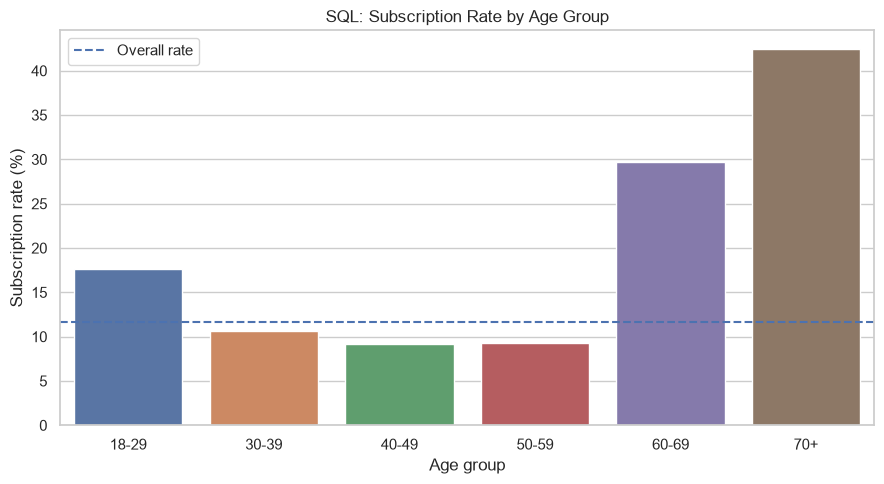

In [47]:
figure, axis = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=age_group_summary,
    x="age_group",
    y="subscription_rate",
    hue="age_group",
    legend=False,
    ax=axis,
)

axis.axhline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
    label="Overall rate",
)

axis.set_title("SQL: Subscription Rate by Age Group")
axis.set_xlabel("Age group")
axis.set_ylabel("Subscription rate (%)")
axis.legend()

plt.tight_layout()
plt.show()

## 9. Subscription Performance by Education

Education categories are compared using customer volume, subscriber count, average age, average balance, and subscription rate.

The `unknown` category is retained as an explicit operational category rather than automatically treated as a null value.

In [48]:
education_summary = display_sql_query(
    "subscription_by_education"
)

### SQL Query: `subscription_by_education`

```sql
-- Subscription performance by education level.

SELECT
    education,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate,
    ROUND(AVG(age), 2) AS average_age,
    ROUND(AVG(balance), 2) AS average_balance
FROM bank_marketing
GROUP BY education
ORDER BY
    subscription_rate DESC,
    client_count DESC;
```

,education,client_count,subscriber_count,subscription_rate,average_age,average_balance
0,tertiary,13301,1996,15.01,39.59,"1,758.42"
1,unknown,1857,252,13.57,44.51,"1,526.75"
2,secondary,23202,2450,10.56,39.96,"1,154.88"
3,primary,6851,591,8.63,45.87,"1,250.95"


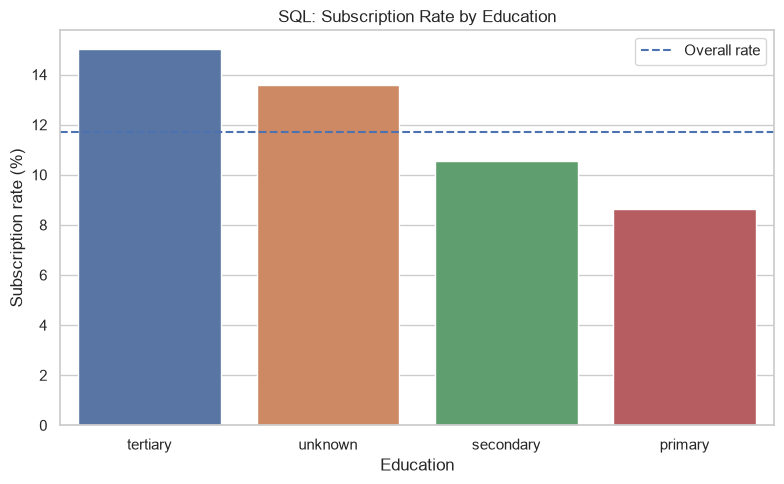

In [49]:
figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=education_summary,
    x="education",
    y="subscription_rate",
    hue="education",
    legend=False,
    ax=axis,
)

axis.axhline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
    label="Overall rate",
)

axis.set_title("SQL: Subscription Rate by Education")
axis.set_xlabel("Education")
axis.set_ylabel("Subscription rate (%)")
axis.legend()

plt.tight_layout()
plt.show()

## 10. Subscription Performance by Contact Type

The communication-channel analysis compares cellular, telephone, and unknown contact types.

The observed differences may reflect customer selection, campaign strategy, historical data collection, or other operational factors. They should not automatically be interpreted as the causal effect of the communication channel.

In [50]:
contact_type_summary = display_sql_query(
    "subscription_by_contact_type"
)

### SQL Query: `subscription_by_contact_type`

```sql
-- Subscription performance by communication channel.

SELECT
    contact,
    COUNT(*) AS client_count,
    SUM(subscribed) AS subscriber_count,
    ROUND(
        100.0 * SUM(subscribed) / COUNT(*),
        2
    ) AS subscription_rate,
    ROUND(
        AVG(call_duration_seconds),
        2
    ) AS average_call_duration_seconds
FROM bank_marketing
GROUP BY contact
ORDER BY
    subscription_rate DESC,
    client_count DESC;
```

,contact,client_count,subscriber_count,subscription_rate,average_call_duration_seconds
0,cellular,29285,4369,14.92,263.01
1,telephone,2906,390,13.42,235.37
2,unknown,13020,530,4.07,252.34


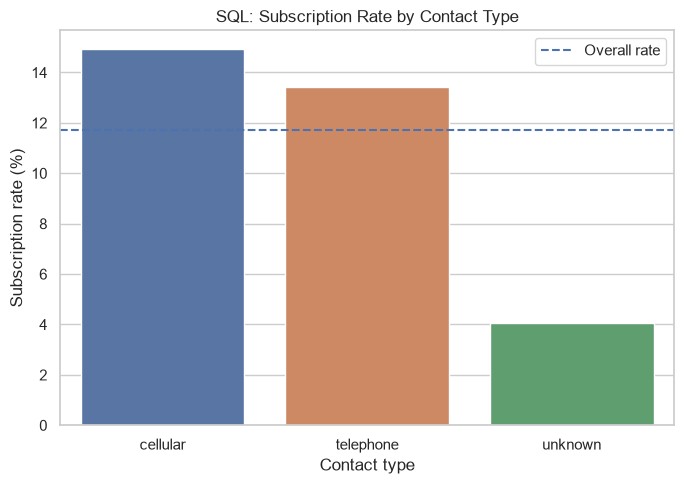

In [51]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=contact_type_summary,
    x="contact",
    y="subscription_rate",
    hue="contact",
    legend=False,
    ax=axis,
)

axis.axhline(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ],
    linestyle="--",
    label="Overall rate",
)

axis.set_title("SQL: Subscription Rate by Contact Type")
axis.set_xlabel("Contact type")
axis.set_ylabel("Subscription rate (%)")
axis.legend()

plt.tight_layout()
plt.show()

## 11. Account Balance by Subscription Status

This query compares average, minimum, and maximum account balances between subscribers and non-subscribers.

Because balance is highly skewed and contains extreme values, the average should be interpreted cautiously. Median-based analysis and statistical testing will be performed later.

In [52]:
balance_by_subscription = display_sql_query(
    "average_balance_by_subscription"
)

### SQL Query: `average_balance_by_subscription`

```sql
-- Account-balance comparison between subscribers and non-subscribers.

SELECT
    subscribed,
    CASE
        WHEN subscribed = 1
            THEN 'Subscription'
        ELSE 'No subscription'
    END AS subscription_label,
    COUNT(*) AS client_count,
    ROUND(AVG(balance), 2) AS average_balance,
    MIN(balance) AS minimum_balance,
    MAX(balance) AS maximum_balance
FROM bank_marketing
GROUP BY subscribed
ORDER BY subscribed;
```

,subscribed,subscription_label,client_count,average_balance,minimum_balance,maximum_balance
0,0,No subscription,39922,"1,303.71",-8019,102127
1,1,Subscription,5289,"1,804.27",-3058,81204


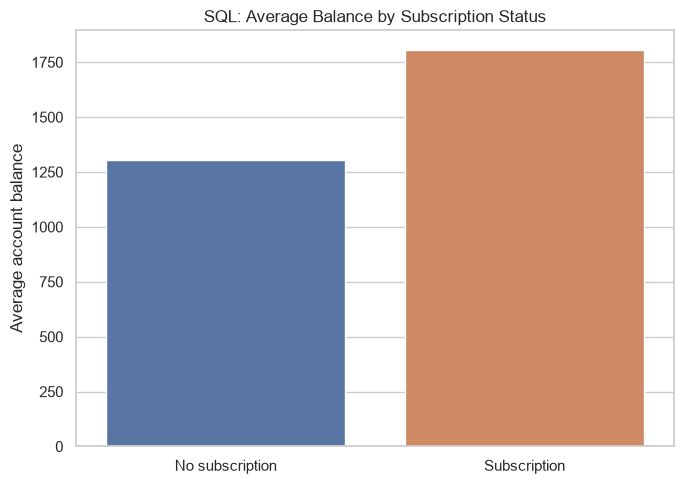

In [53]:
figure, axis = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=balance_by_subscription,
    x="subscription_label",
    y="average_balance",
    hue="subscription_label",
    legend=False,
    ax=axis,
)

axis.set_title("SQL: Average Balance by Subscription Status")
axis.set_xlabel("")
axis.set_ylabel("Average account balance")

plt.tight_layout()
plt.show()

## 12. Scalable Segment Ranking

The scalable-segment query combines several business dimensions using `UNION ALL`.

It then:

1. Removes very small segments.
2. Uses `ROW_NUMBER()` with `PARTITION BY` to rank segments independently within each feature.
3. Prioritizes subscription rate and then subscriber volume.

The minimum segment size is 452 clients, approximately 1% of the dataset.

In [54]:
scalable_segment_ranking = display_sql_query(
    "scalable_segment_ranking"
)

### SQL Query: `scalable_segment_ranking`

```sql
-- Rank sufficiently large segments across several business dimensions.

WITH segment_performance AS (
    SELECT
        'job' AS feature,
        job AS segment,
        COUNT(*) AS client_count,
        SUM(subscribed) AS subscriber_count,
        ROUND(
            100.0 * SUM(subscribed) / COUNT(*),
            2
        ) AS subscription_rate
    FROM bank_marketing
    GROUP BY job

    UNION ALL

    SELECT
        'contact' AS feature,
        contact AS segment,
        COUNT(*) AS client_count,
        SUM(subscribed) AS subscriber_count,
        ROUND(
            100.0 * SUM(subscribed) / COUNT(*),
            2
        ) AS subscription_rate
    FROM bank_marketing
    GROUP BY contact

    UNION ALL

    SELECT
        'month' AS feature,
        contact_month AS segment,
        COUNT(*) AS client_count,
        SUM(subscribed) AS subscriber_count,
        ROUND(
            100.0 * SUM(subscribed) / COUNT(*),
            2
        ) AS subscription_rate
    FROM bank_marketing
    GROUP BY contact_month

    UNION ALL

    SELECT
        'previous_outcome' AS feature,
        previous_outcome AS segment,
        COUNT(*) AS client_count,
        SUM(subscribed) AS subscriber_count,
        ROUND(
            100.0 * SUM(subscribed) / COUNT(*),
            2
        ) AS subscription_rate
    FROM bank_marketing
    GROUP BY previous_outcome
),
eligible_segments AS (
    SELECT
        feature,
        segment,
        client_count,
        subscriber_count,
        subscription_rate
    FROM segment_performance
    WHERE client_count >= 452
),
ranked_segments AS (
    SELECT
        feature,
        segment,
        client_count,
        subscriber_count,
        subscription_rate,
        ROW_NUMBER() OVER (
            PARTITION BY feature
            ORDER BY
                subscription_rate DESC,
                subscriber_count DESC
        ) AS segment_rank
    FROM eligible_segments
)
SELECT
    feature,
    segment,
    client_count,
    subscriber_count,
    subscription_rate,
    segment_rank
FROM ranked_segments
ORDER BY
    feature,
    segment_rank;
```

,feature,segment,client_count,subscriber_count,subscription_rate,segment_rank
0,contact,cellular,29285,4369,14.92,1
1,contact,telephone,2906,390,13.42,2
2,contact,unknown,13020,530,4.07,3
3,job,student,938,269,28.68,1
4,job,retired,2264,516,22.79,2
5,job,unemployed,1303,202,15.50,3
6,job,management,9458,1301,13.76,4
7,job,admin.,5171,631,12.20,5
8,job,self-employed,1579,187,11.84,6
9,job,technician,7597,840,11.06,7


In [55]:
best_scalable_segments = (
    scalable_segment_ranking
    .query("segment_rank == 1")
    .sort_values("subscription_rate", ascending=False)
    .reset_index(drop=True)
)

display(best_scalable_segments)

,feature,segment,client_count,subscriber_count,subscription_rate,segment_rank
0,previous_outcome,success,1511,978,64.73,1
1,month,mar,477,248,51.99,1
2,job,student,938,269,28.68,1
3,contact,cellular,29285,4369,14.92,1


### Scalable-Segment Interpretation

The ranking identifies strong descriptive segments while excluding extremely small groups.

However, each feature is analyzed independently. A segment's strong rate may overlap with other influential characteristics.

For example, customers contacted in March may differ from customers contacted in other months in age, job, previous campaign history, or other variables.

A multivariable machine-learning model will later evaluate combinations of features.

## 13. SQL and Pandas Consistency Validation

The following validation independently recalculates selected SQL results using Pandas.

Agreement between SQL and Pandas provides additional confidence that:

- Grouping logic is correct.
- Target aggregation is correct.
- SQL segment definitions match the analytical definitions.

In [56]:
with sqlite3.connect(DATABASE_PATH) as connection:
    database_data = pd.read_sql_query(
        """
        SELECT *
        FROM bank_marketing
        ORDER BY campaign_record_id;
        """,
        connection,
    )

print(f"Database rows loaded into Pandas: {len(database_data)}")

display(database_data.head())

Database rows loaded into Pandas: 45211


,campaign_record_id,age,job,marital,education,default_status,balance,housing_loan,personal_loan,contact,contact_day,contact_month,call_duration_seconds,campaign_contacts,days_since_previous_contact,previous_contacts,previous_outcome,subscribed
0,1,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,2,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,3,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,4,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,5,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [57]:
pandas_job_summary = (
    database_data
    .groupby("job", as_index=False)
    .agg(
        client_count=(
            "campaign_record_id",
            "size",
        ),
        subscriber_count=(
            "subscribed",
            "sum",
        ),
        average_balance=(
            "balance",
            "mean",
        ),
    )
)

pandas_job_summary["subscription_rate"] = (
    pandas_job_summary["subscriber_count"]
    .div(pandas_job_summary["client_count"])
    .mul(100)
    .round(2)
)

pandas_job_summary["average_balance"] = (
    pandas_job_summary["average_balance"]
    .round(2)
)

sql_job_validation = (
    job_summary
    .sort_values("job")
    .reset_index(drop=True)
)

pandas_job_validation = (
    pandas_job_summary[
        [
            "job",
            "client_count",
            "subscriber_count",
            "subscription_rate",
            "average_balance",
        ]
    ]
    .sort_values("job")
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    sql_job_validation,
    pandas_job_validation,
    check_dtype=False,
)

print(
    "SQL and Pandas job summaries match successfully."
)

SQL and Pandas job summaries match successfully.


In [58]:
pandas_total_clients = len(database_data)
pandas_subscribers = int(
    database_data["subscribed"].sum()
)

pandas_non_subscribers = (
    pandas_total_clients
    - pandas_subscribers
)

pandas_subscription_rate = round(
    100
    * pandas_subscribers
    / pandas_total_clients,
    2,
)

assert pandas_total_clients == int(
    dataset_overview.loc[
        0,
        "total_clients",
    ]
)

assert pandas_subscribers == int(
    dataset_overview.loc[
        0,
        "subscribers",
    ]
)

assert pandas_non_subscribers == int(
    dataset_overview.loc[
        0,
        "non_subscribers",
    ]
)

assert pandas_subscription_rate == float(
    dataset_overview.loc[
        0,
        "overall_subscription_rate",
    ]
)

print(
    "SQL and Pandas dataset-overview results "
    "match successfully."
)

SQL and Pandas dataset-overview results match successfully.


## 14. Final SQL Analysis Validation

These checks confirm that all main SQL result tables cover the expected records and contain valid conversion rates.

In [59]:
assert len(queries) == 11
assert len(results) == 11
assert len(database_data) == 45_211

summary_tables = [
    job_summary,
    education_summary,
    contact_type_summary,
    month_summary,
    previous_outcome_summary,
    age_group_summary,
    campaign_contact_summary,
]

for summary_table in summary_tables:
    assert (
        summary_table["client_count"].sum()
        == 45_211
    )

    assert summary_table[
        "subscription_rate"
    ].between(0, 100).all()

assert (
    balance_by_subscription["client_count"].sum()
    == 45_211
)

assert set(
    balance_by_subscription["subscribed"]
) == {0, 1}

assert not scalable_segment_ranking.empty

assert (
    scalable_segment_ranking["client_count"]
    >= 452
).all()

assert (
    best_scalable_segments["feature"].nunique()
    == len(best_scalable_segments)
)

print(
    "All SQL notebook business-analysis "
    "validation checks passed successfully."
)

All SQL notebook business-analysis validation checks passed successfully.


## 15. SQL Business Findings

The SQLite analysis produced reproducible business summaries using aggregations, CTEs, `CASE WHEN`, `UNION ALL`, and window functions.

Main descriptive findings:

- The overall subscription rate is 11.7%.
- Students have the highest job-level subscription rate, while management contributes the largest share of total subscribers among job categories.
- Cellular contact has a higher subscription rate than unknown contact records.
- March, September, and October show high observed subscription rates, although their campaign volumes differ substantially.
- Customers with a previous successful campaign outcome have a substantially higher subscription rate.
- Subscribers have a higher average balance than non-subscribers, but the balance distribution is highly skewed.
- Older age groups show relatively high subscription rates but represent smaller customer segments.
- Subscription rates decrease across groups with more current-campaign contacts, although this does not establish that repeated contact causes lower conversion.
- SQL and Pandas calculations produced consistent results.

These findings are observational and will be examined further using statistical tests and multivariable machine-learning models.